# Viscosity profile

In [112]:
using CairoMakie, GeoParams

n  = 64
lz = 2890e3
z  = LinRange(-lz, 0, n)

64-element LinRange{Float64, Int64}:
 -2.89e6, -2.84413e6, -2.79825e6, …, -137619.0, -91746.0, -45873.0, 0.0

### Diffusion viscosity

$\eta_{\text{diff}} = A^{-1} \exp( \frac{E + PV}{R  T})$

In [113]:
visc_diff(T, P, A, E, V; R = 8.3145) = A^(-1) * exp((E + P*V) / (R * T))
visc_diff(T, P, data::NamedTuple; R = 8.3145) = visc_diff(T, P, data.A, data.E, data.V; R = R)

visc_diff (generic function with 2 methods)

### Dislocation viscosity

$\eta_{\text{diff}} = \dot{\varepsilon}_{II}^{\frac{1-n}{n}} A^{\frac{-1}{n}} \exp( \frac{E + PV}{n R  T})$

In [114]:
visc_disl(εII, T, P, n, A, E, V; R = 8.3145) = εII^((1-n)/n) * A^(-1/n) * exp((E + P*V) / (n * R * T))
visc_disl(εII, T, P, data::NamedTuple; R = 8.3145) = visc_disl(εII, T, P, data.n, data.A, data.E, data.V; R = R)

visc_disl (generic function with 2 methods)

## Effective viscosity

$\eta = \frac{1}{\frac{1}{\eta}  + \frac{1}{\eta}}$

In [115]:
function visc_eff(εII, T, P,  data_diff::NamedTuple, data_disl::NamedTuple; R = 8.3145)
    η_diff = visc_diff(T, P, data_diff; R = R)
    η_disl = visc_disl(εII, T, P, data_disl; R = R)
    return η_diff * η_disl / (η_diff +  η_disl)
    return 1 / (1/η_diff +  1/η_disl)
end
function visc_eff(εII, T, P, ::Nothing, data_disl::NamedTuple; R = 8.3145)
    η_disl = visc_disl(εII, T, P, data_disl; R = R)
end
function visc_eff(εII, T, P, data_diff::NamedTuple, ::Nothing; R = 8.3145)
    η_diff = visc_diff(T, P, data_diff; R = R)
end


visc_eff (generic function with 3 methods)

## Initial thermal and pressure profiles

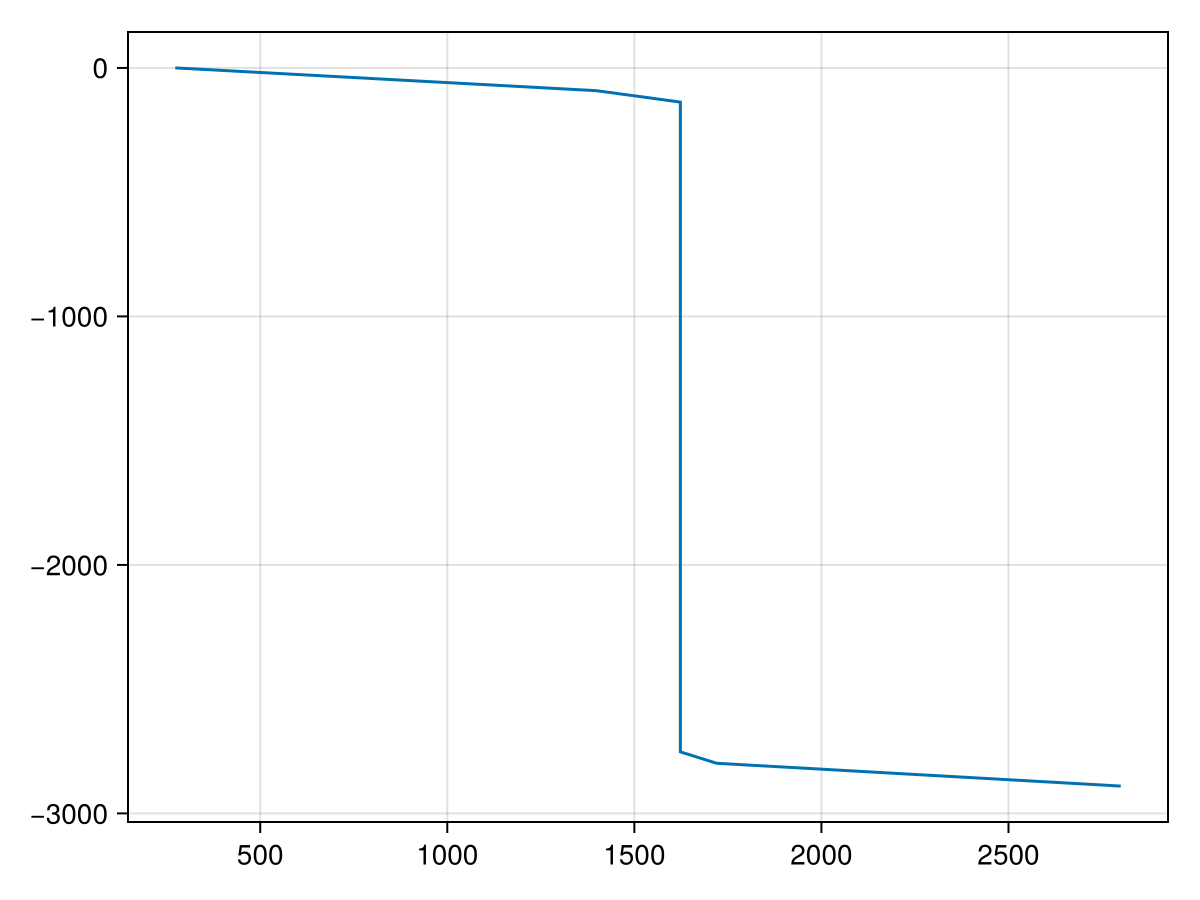

In [116]:
# Smooth switch
S(ξ) = 0.5 * (1.0 + tanh(ξ))

function T_field(
    z;
    Lz=2890.0,
    n=1,
    m=1,
    Ttop=273.0,
    Tbot=3800.0,
    Tm=1600.0 + 200,
    zm=100.0,
    gamma=0.35,
    delta_t=110e3,
    delta_b=100e3,
    w_t=20e3,
    w_b=25e3,
)
    # Enforce an isothermal interior (1600 K by default) and keep smooth BL transitions.
    Tmid = Tm
    s_t = S((z - delta_t) / w_t)
    s_b = S(((Lz - delta_b) - z) / w_b)
    T_topBL = Ttop + (Tmid - Ttop) * (z / delta_t)
    T_botBL = Tmid + (Tbot - Tmid) * ((z - (Lz - delta_b)) / delta_b)
    background = (1.0 - s_t) * T_topBL + (s_t * s_b) * Tmid + (1.0 - s_b) * T_botBL

    return background 
end


T = T_field.(
    -z; 
    Lz      = lz,
    Ttop    = 273.0,
    Tbot    = 2800.0,
    Tm      = 1350.0 + 273,
    # delta_b = 250.0,
    w_t     = 20,
    w_b     = 20
)

P = @. -3300 * 9.81 * z;
lines(T, z./1e3)

### Phases as function of depth

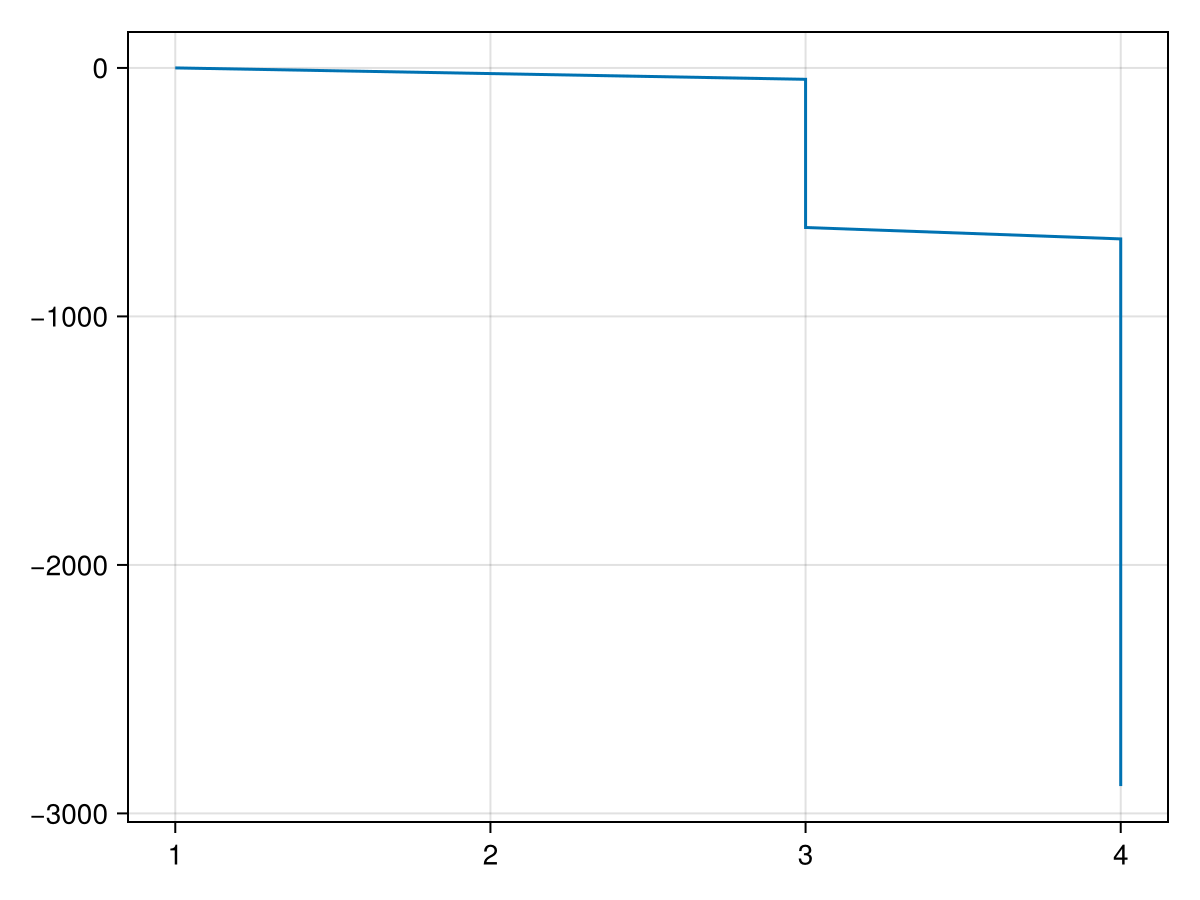

In [117]:
function get_phase(z)
    if z > -20e3
        return 1 # upper crust
    elseif z > -40e3
        return 2 # lower crust
    elseif z > -660e3
        return 3 # upper mantle
    else
        return 4 # lower mantle
    end
end

phase = get_phase.(z)
lines(phase, z./1e3)

## Rheology

Rheologies from Table S2 of [Li et al 2026](https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2025JB032510?saml_referrer)

### Crust

In [ ]:
rheo_upper_crust = DislocationCreep(
    A = 5.e-18Pa^(-23 // 10) / s,
    n = 2.3NoUnits,
    E = 154.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
)

rheo_lower_crust = DislocationCreep(
    A = 2e-23Pa^(-32 // 10) / s,
    n = 3.2NoUnits,
    E = 238.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
)

DislocationCreep: Name = , n=3.2, r=0.0, A=2.0e-23 Pa^-3.2 s^-1.0, E=238000.0 J mol^-1.0, V=8.0e-6 m^3.0 mol^-1.0, FT=1.0, FE=1.0, Apparatus=3

In [119]:
disl_upper_crust = (;
    A = 5.e-18,
    n = 2.3,
    E = 154.0e3,
    V = 8.0e-6,
    R = 8.3145
)
rheo_upper_crust_noGP = nothing, disl_upper_crust

disl_lower_crust = (;
    A = 2e-23,
    n = 3.2,
    E = 238.0e3,
    V = 8.0e-6,
    r = 0.0,
    R = 8.3145
)
rheo_lower_crust_noGP = nothing, disl_lower_crust


(nothing, (A = 2.0e-23, n = 3.2, E = 238000.0, V = 8.0e-6, r = 0.0, R = 8.3145))

### Lithospheric mantle

In [120]:
disl_mantle = DislocationCreep(
    A = 1.1e-17Pa^(-35 // 10) / s,
    n = 3.5NoUnits,
    E = 530.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
)
diff_mantle = DiffusionCreep(
    A = 2.2e-10Pa^(-1) * s^(-1),       # material specific rheological parameter
    E = 375e3J / mol,                  # activation energy
    V = 4e-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    p = 0NoUnits,                      # grain size exponent
)
rheo_mantle = CompositeRheology(disl_mantle, diff_mantle)

--⟦▪̲̅▫̲̅▫̲̅▫̲̅----⟦▪̲̅▫̲̅▫̲̅▫̲̅--


In [121]:
disl_mantle = (;
    A = 1.1e-17,
    n = 3.5,
    E = 530.0e3,
    V = 8.0e-6,
    r = 0.0,
    R = 8.3145
)
diff_mantle = (;
    A = 2.2e-10,       # material specific rheological parameter
    E = 375e3,                  # activation energy
    V = 4e-6,                 # activation Volume
    n = 1.0,                    # power-law exponent
    r = 0.0,                    # exponent of water-fugacity
    p = 0,                      # grain size exponent
)
rheo_mantle_noGP = diff_mantle, disl_mantle

((A = 2.2e-10, E = 375000.0, V = 4.0e-6, n = 1.0, r = 0.0, p = 0), (A = 1.1e-17, n = 3.5, E = 530000.0, V = 8.0e-6, r = 0.0, R = 8.3145))

### Lower mantle

In [122]:
rheo_lower_mantle = DiffusionCreep(
    A = 2.2e-13Pa^(-1) * s^(-1),       # material specific rheological parameter
    E = 300e3J / mol,                  # activation energy
    V = 2e-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    p = 0NoUnits,                      # grain size exponent
    Apparatus = Invariant,
)

DiffusionCreep: Name = , n=1.0, r=0.0, p=0.0, A=2.2e-13 Pa^-1.0 s^-1.0, E=300000.0 J mol^-1.0, V=2.0e-6 m^3.0 mol^-1.0, FT=1.0, FE=1.0

In [123]:
diff_lower_mantle = (;
    A = 2.2e-13,                # material specific rheological parameter
    E = 300e3,                  # activation energy
    V = 2e-6,                   # activation Volume
    n = 1.0,                    # power-law exponent
    r = 0.0,                    # exponent of water-fugacity
    p = 0,                      # grain size exponent
    
)
rheo_lower_mantle_noGP = diff_lower_mantle, nothing


((A = 2.2e-13, E = 300000.0, V = 2.0e-6, n = 1.0, r = 0.0, p = 0), nothing)

### Resulting rheology

In [124]:
rheology = rheo_upper_crust, rheo_lower_crust, rheo_mantle, rheo_lower_mantle;
rheology_noGP = rheo_upper_crust_noGP, rheo_lower_crust_noGP, rheo_mantle_noGP, rheo_lower_mantle_noGP;

# Compute viscosity profile with GeoParams

In [125]:
εII = 1e-15
η = zeros(n)
for i in eachindex(z)
    phaseᵢ = phase[i]
    Tᵢ = T[i]
    Pᵢ = P[i]
    args = (; T = Tᵢ, P = Pᵢ, dt=Inf)
    η[i] = clamp(
        compute_viscosity_εII(rheology[phaseᵢ], εII, args) * 2, 
        1e18, 
        1e23
    )
end

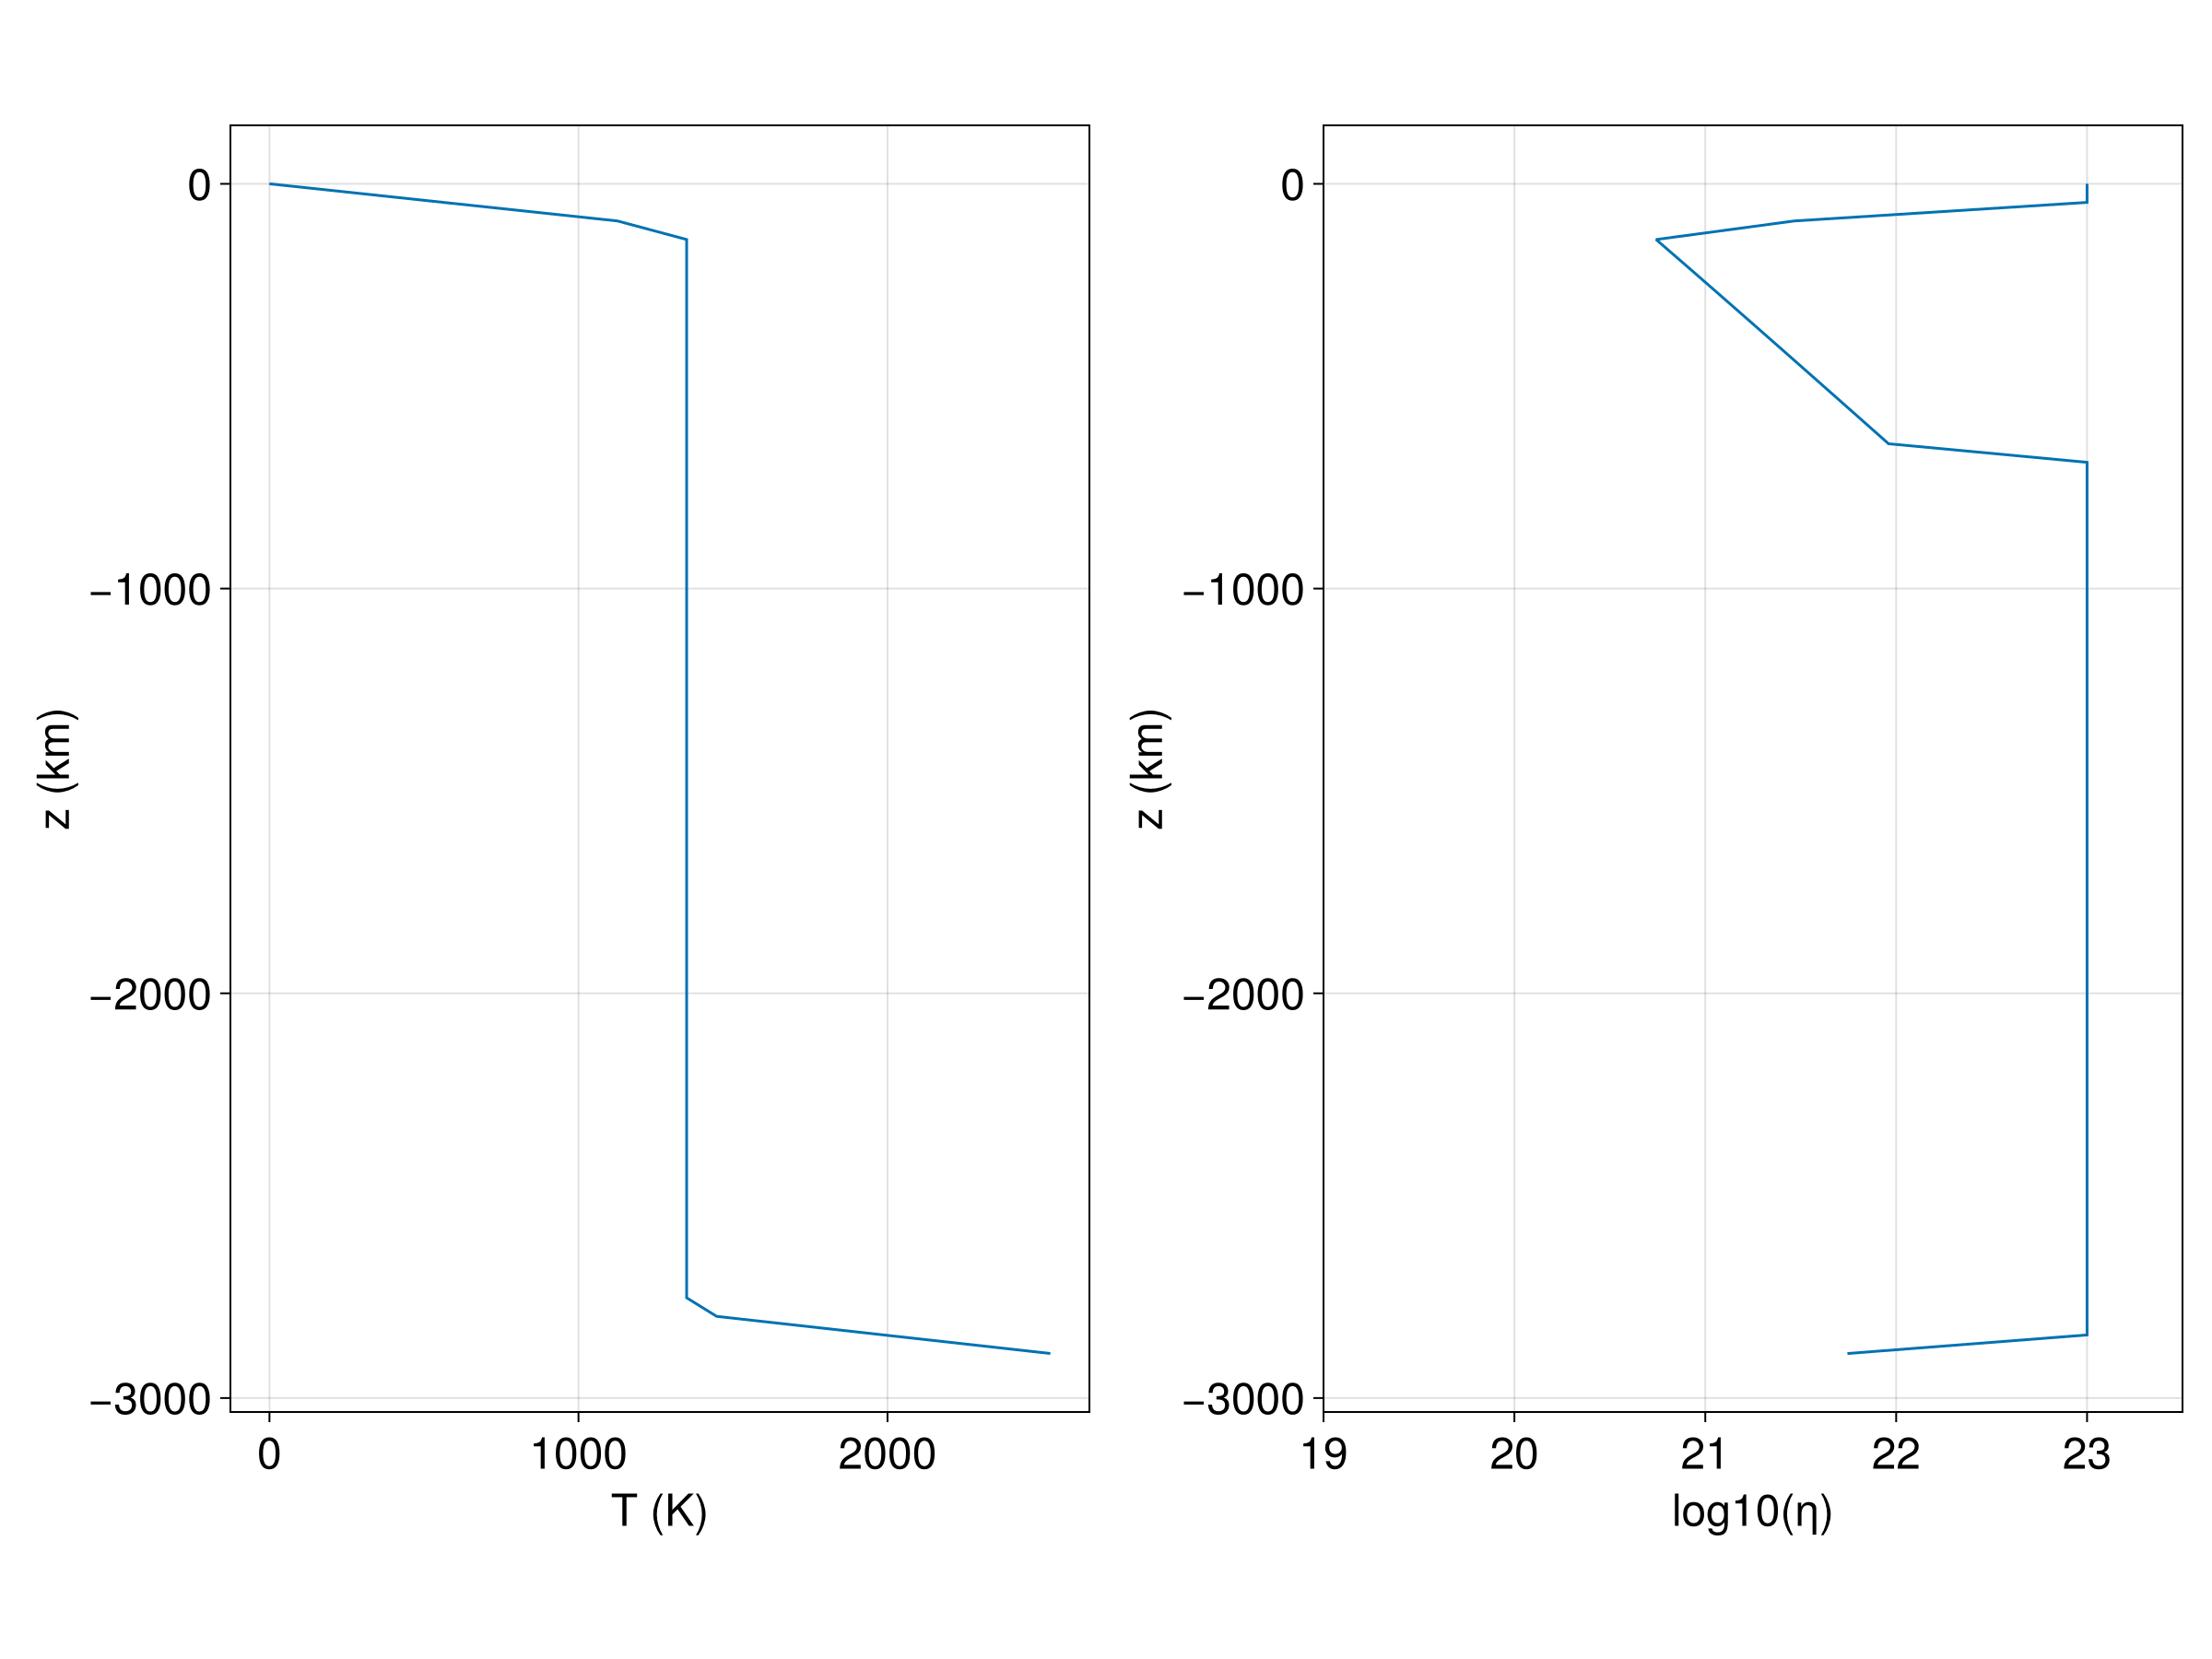

In [135]:
fig = Figure(size = (1200, 900), fontsize = 24)
ax1 = Axis(fig[1, 1], aspect = 2 / 3, ylabel = "z (km)", xlabel = "T (K)")
ax2 = Axis(fig[1, 2], aspect = 2 / 3, ylabel = "z (km)", xlabel = "log10(η)")
lines!(ax1, T .- 273, z./1e3)
lines!(ax2, log10.(η), z./1e3)
xlims!(ax2, 19, 23.5)
ax2.xticks = 19:23.5
fig

# Compute viscosity profile without GeoParams

In [136]:
εII = 1e-15
η_noGP = zeros(n)
# rheo_mantle_noGP = diff_mantle, disl_mantle
# rheo_mantle_noGP = nothing, disl_mantle
rheology_noGP = rheo_upper_crust_noGP, rheo_lower_crust_noGP, rheo_mantle_noGP, rheo_lower_mantle_noGP;

for i in eachindex(z)
    phaseᵢ = phase[i]
    Tᵢ = T[i]
    Pᵢ = P[i]
    args = (; T = Tᵢ, P = Pᵢ, dt=Inf)
    η_noGP[i] = clamp(
        visc_eff(εII, Tᵢ, Pᵢ, rheology_noGP[phaseᵢ]...),
        1e18,
        1e23
    )
end

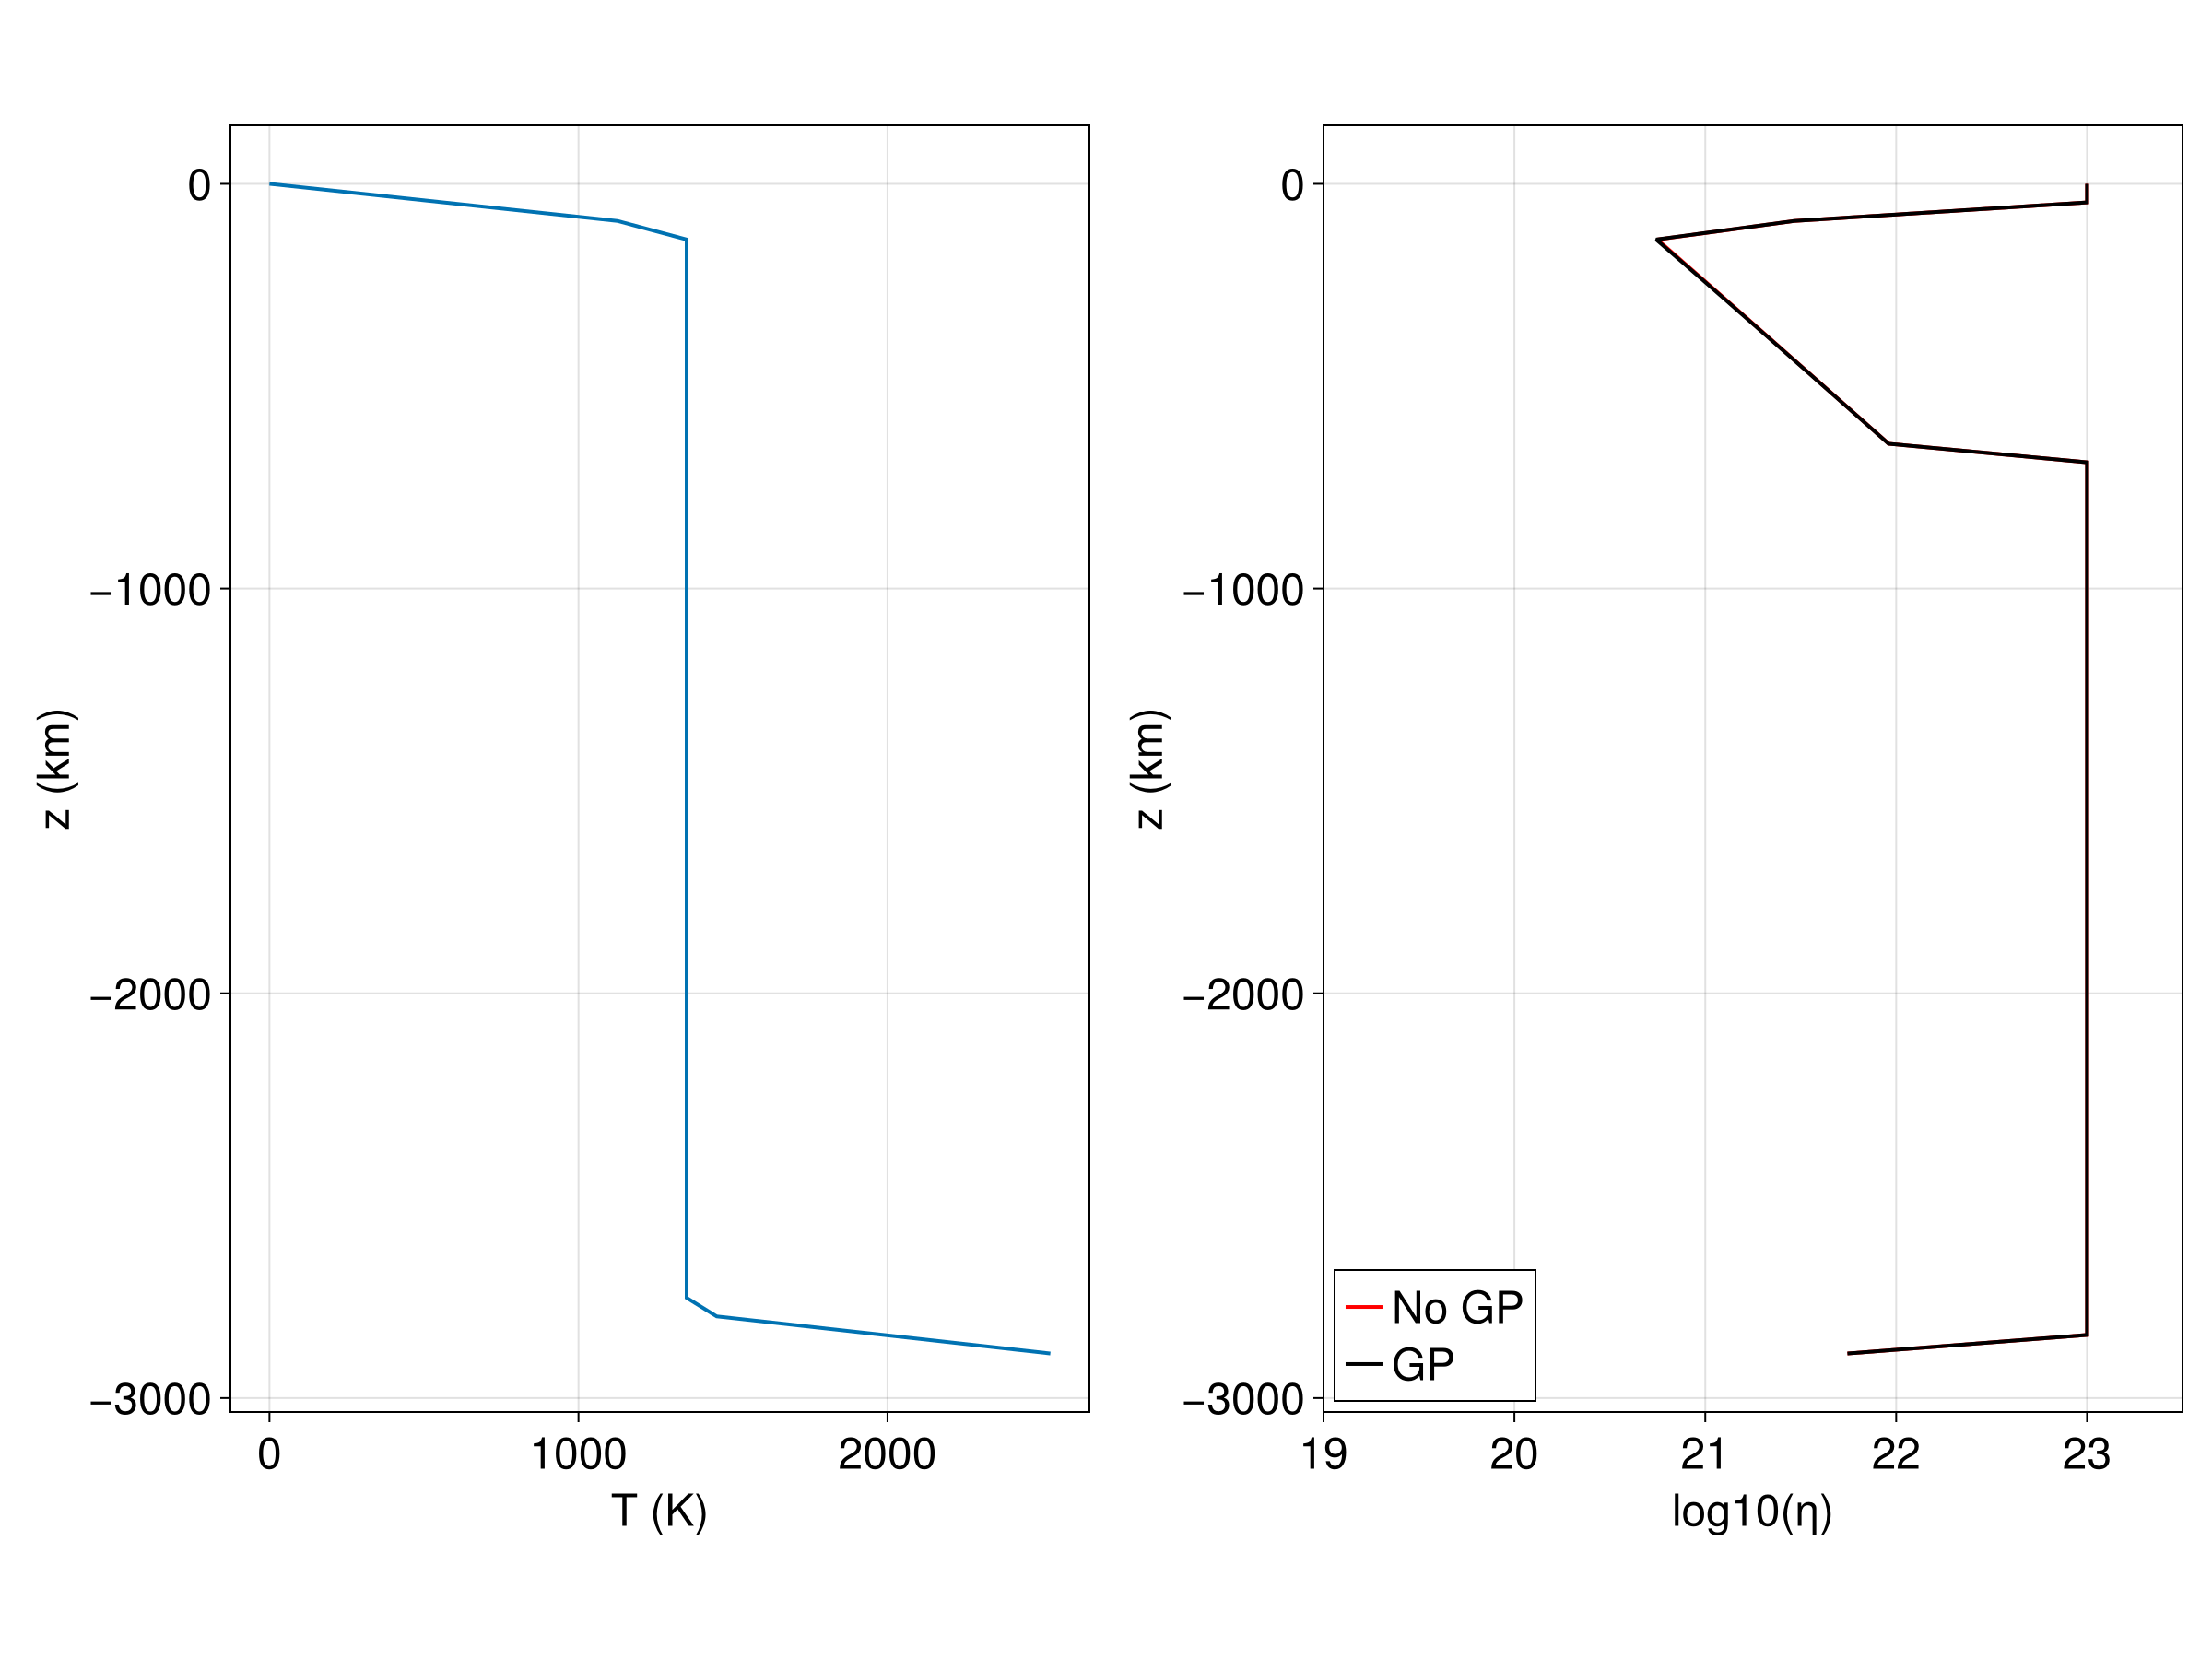

In [137]:
fig = Figure(size = (1200, 900), fontsize = 24)
ax1 = Axis(fig[1, 1], aspect = 2 / 3, ylabel = "z (km)", xlabel = "T (K)")
ax2 = Axis(fig[1, 2], aspect = 2 / 3, ylabel = "z (km)", xlabel = "log10(η)")
lines!(ax1, T .- 273, z./1e3, linewidth = 2)
lines!(ax2, log10.(η_noGP), z./1e3, color = :red  , linewidth = 2, label = "No GP")
lines!(ax2, log10.(η)     , z./1e3, color = :black, linewidth = 2, label = "GP")
xlims!(ax2, 19, 23.5)
axislegend(ax2, position = :lb)
ax2.xticks = 19:23.5
fig

In [138]:
Ti, Pi = 1600, 300e3 * 9.81 * 3300
visc_eff(εII, Ti, Pi, rheology_noGP[3]...)

1.6705382453619083e21

In [139]:
visc_disl(εII, Ti, Pi, rheology_noGP[3][2]) # dislocation

1.6897107235751078e21

In [140]:
visc_disl(εII, Ti, Pi, rheology_noGP[3][1]) # diffusion


1.4722803989872565e23

In [141]:
args = (; T = Ti, P = Pi, dt=Inf)
compute_viscosity_εII(rheology[3], εII, args)

8.305571213626295e20

In [142]:
compute_viscosity_εII(rheology[3].elements[1], εII, args) # dislocation

8.448553617875526e20

In [143]:
compute_viscosity_εII(rheology[3].elements[2], εII, args) # diffusion


4.907601329957524e22

## Creep-law parameters by phase

```latex
\begin{table}[htbp]
\centering
\caption{Creep-law parameters by material phase in \texttt{ConvectionRheology.ipynb}.}
\label{tab:convection-rheology-params}
\small
\begin{tabular}{llcccccccc}
\hline
Phase & Depth range & $A_{\mathrm{disl}}$ & $n_{\mathrm{disl}}$ & $E_{\mathrm{disl}}$ & $V_{\mathrm{disl}}$ & $A_{\mathrm{diff}}$ & $n_{\mathrm{diff}}$ & $E_{\mathrm{diff}}$ & $V_{\mathrm{diff}}$ \\
 & (km) & (Pa$^{-n}$ s$^{-1}$) &  & (J mol$^{-1}$) & (m$^3$ mol$^{-1}$) & (Pa$^{-1}$ s$^{-1}$) &  & (J mol$^{-1}$) & (m$^3$ mol$^{-1}$) \\
\hline
Upper crust (1) & $0$ to $-20$ & $5.0\times10^{-18}$ & 2.3 & $154\times10^{3}$ & $8.0\times10^{-6}$ & -- & -- & -- & -- \\
Lower crust (2) & $-20$ to $-40$ & $2.0\times10^{-23}$ & 3.2 & $238\times10^{3}$ & $8.0\times10^{-6}$ & -- & -- & -- & -- \\
Upper mantle (3) & $-40$ to $-660$ & $1.1\times10^{-17}$ & 3.5 & $530\times10^{3}$ & $8.0\times10^{-6}$ & $2.2\times10^{-10}$ & 1.0 & $375\times10^{3}$ & $4.0\times10^{-6}$ \\
Lower mantle (4) & $< -660$ & -- & -- & -- & -- & $2.2\times10^{-13}$ & 1.0 & $300\times10^{3}$ & $2.0\times10^{-6}$ \\
\hline
\end{tabular}
\end{table}
```


## Creep-law parameters by phase

| Phase | Depth range (km) | A_disl (Pa^-n s^-1) | n_disl | E_disl (J mol^-1) | V_disl (m^3 mol^-1) | A_diff (Pa^-1 s^-1) | n_diff | E_diff (J mol^-1) | V_diff (m^3 mol^-1) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Upper crust (1) | 0 to -20 | 5.0e-18 | 2.3 | 154e3 | 8.0e-6 | -- | -- | -- | -- |
| Lower crust (2) | -20 to -40 | 2.0e-23 | 3.2 | 238e3 | 8.0e-6 | -- | -- | -- | -- |
| Upper mantle (3) | -40 to -660 | 1.1e-17 | 3.5 | 530e3 | 8.0e-6 | 2.2e-10 | 1.0 | 375e3 | 4.0e-6 |
| Lower mantle (4) | < -660 | -- | -- | -- | -- | 2.2e-13 | 1.0 | 300e3 | 2.0e-6 |
